# 00.1 — Global-6 data overview

Day 4 uses **subsensor 0 only**. Sensors 1–6 are masters; sensor 7 is the final slave.

In [1]:
from pathlib import Path
import sys, json, numpy as np, matplotlib.pyplot as plt
ROOT=next(p for p in (Path.cwd().resolve(),*Path.cwd().resolve().parents) if (p/"Networks"/"TCOCNNv3.py").exists())
sys.path[:0]=[str(ROOT/"Networks"),str(ROOT/"Evaluation Seminar"/"Day_03"),str(ROOT/"Evaluation Seminar"/"Day_04")]
from day4_utils import load_sensor_domains
domains,audit=load_sensor_domains(channel=0,calibration=1,gas="acetone")
sensors=list(domains); masters,target=sensors[:6],sensors[6]
print("Masters:",masters,"| slave:",target,"| input:",domains[target]["train"]["X"].shape[1:])
rows=[{"split":s,"cycles":audit["rows"][s],"UGMs":audit["groups"][s]} for s in ["train","val","test"]]
try:
 import pandas as pd; display(pd.DataFrame(rows))
except ImportError: print(rows)

Masters: ['54118801', '54120037', '54120457', '54156953', '84746449', '84748697'] | slave: 84749569 | input: (1, 1440, 1)
[{'split': 'train', 'cycles': 602, 'UGMs': 137}, {'split': 'val', 'cycles': 86, 'UGMs': 19}, {'split': 'test', 'cycles': 178, 'UGMs': 40}]


## Splits and measured cycles

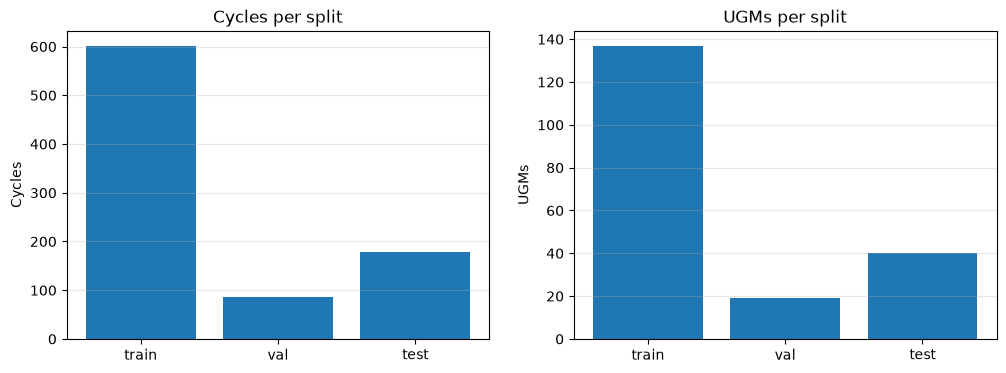

In [2]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar([r["split"] for r in rows],[r["cycles"] for r in rows])
axes[1].bar([r["split"] for r in rows],[r["UGMs"] for r in rows])
axes[0].set(title="Cycles per split",ylabel="Cycles"); axes[1].set(title="UGMs per split",ylabel="UGMs")
for ax in axes: ax.grid(True,axis="y",alpha=.3)
plt.show()

## The same physical cycle on every device

Each curve is subsensor 0. The device shift motivates transfer.

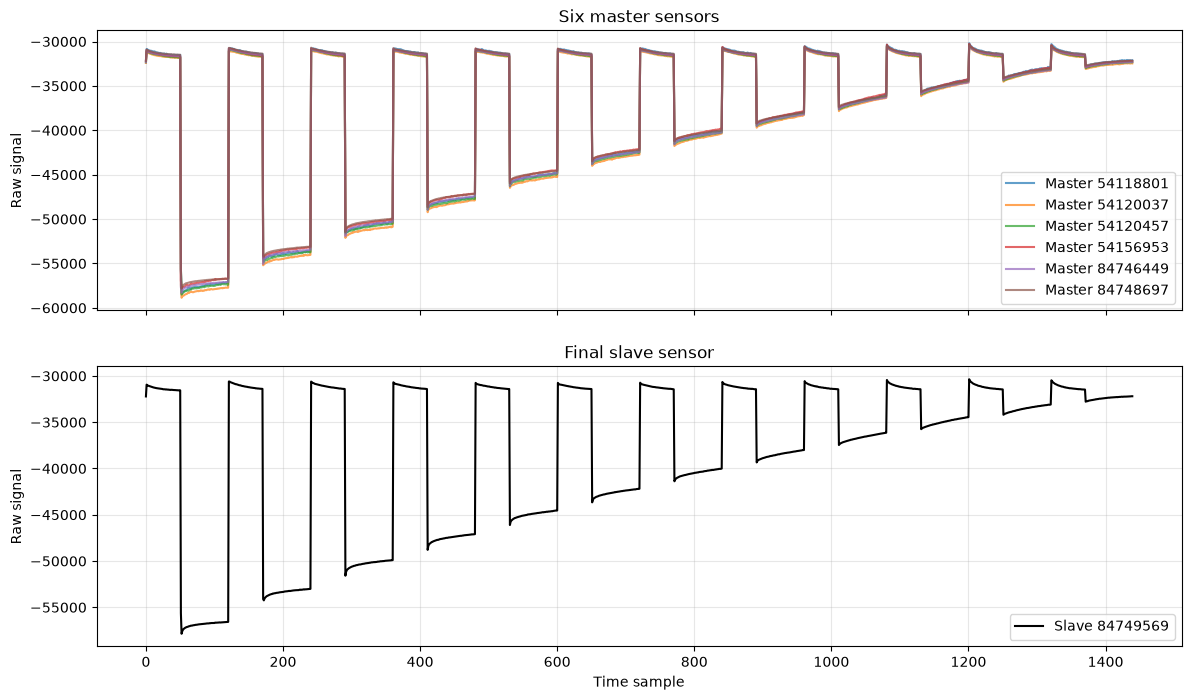

In [3]:
fig,axes=plt.subplots(2,1,figsize=(14,8),sharex=True)
for s in masters: axes[0].plot(domains[s]["train"]["X"][0,0,:,0],alpha=.7,label=f"Master {s}")
axes[1].plot(domains[target]["train"]["X"][0,0,:,0],color="black",label=f"Slave {target}")
axes[0].set(title="Six master sensors",ylabel="Raw signal"); axes[1].set(title="Final slave sensor",xlabel="Time sample",ylabel="Raw signal")
for ax in axes: ax.legend(); ax.grid(True,alpha=.3)
plt.show()

## Acetone target distribution

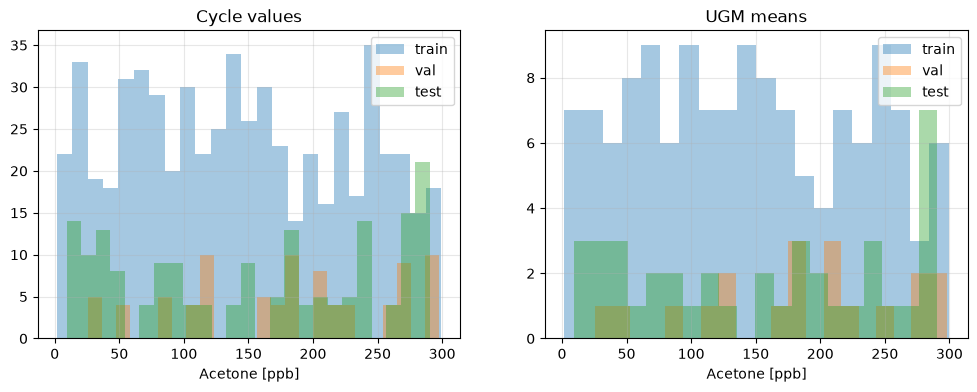

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
for s in ["train","val","test"]:
 y=domains[target][s]["y"]; g=domains[target][s]["groups"]
 axes[0].hist(y,bins=25,alpha=.4,label=s)
 axes[1].hist([y[g==u].mean() for u in np.unique(g)],bins=20,alpha=.4,label=s)
axes[0].set(title="Cycle values",xlabel="Acetone [ppb]"); axes[1].set(title="UGM means",xlabel="Acetone [ppb]")
for ax in axes: ax.legend(); ax.grid(True,alpha=.3)
plt.show()